## Step 1 : load data and librarys 


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel("Netflix_Dataset.xlsx")
df.head(),df.description,df.notnull().sum() # Check for missing values 

(  show_id     type    title            director  \
 0      s1    Movie  Title 1        Greta Gerwig   
 1      s2    Movie  Title 2       Taika Waititi   
 2      s3  TV Show  Title 3        Bong Joon-ho   
 3      s4    Movie  Title 4  Guillermo del Toro   
 4      s5    Movie  Title 5      Anurag Kashyap   
 
                                                 cast  country date_added  \
 0       Scarlett Johansson, Ryan Reynolds, Brad Pitt   Canada 2023-09-10   
 1         Ryan Reynolds, Natalie Portman, Alia Bhatt    Japan 2017-05-10   
 2  Leonardo DiCaprio, Scarlett Johansson, Natalie...    Spain 2018-07-18   
 3       Ryan Reynolds, Brad Pitt, Scarlett Johansson  Germany 2018-02-04   
 4   Shah Rukh Khan, Natalie Portman, Chris Hemsworth   Canada 2017-12-31   
 
    release_year rating   duration              listed_in  \
 0          2016  TV-PG  2 Seasons  Romantic, Documentary   
 1          1998      G  1 Seasons  Documentary, Thriller   
 2          2013  TV-14    133 min  Doc

## Step 2 : clean data and convert data

In [6]:
df.drop_duplicates(inplace=True)
df.dropna(subset=["title"], inplace=True)

# convert data

df["date_added"] = pd.to_datetime(df["date_added"], errors = "coerce")





## Step 3 : Type Distribution 

C:\Users\91935\AppData\Local\Temp\ipykernel_15676\1659946776.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df , x= "type", palette="viridis")


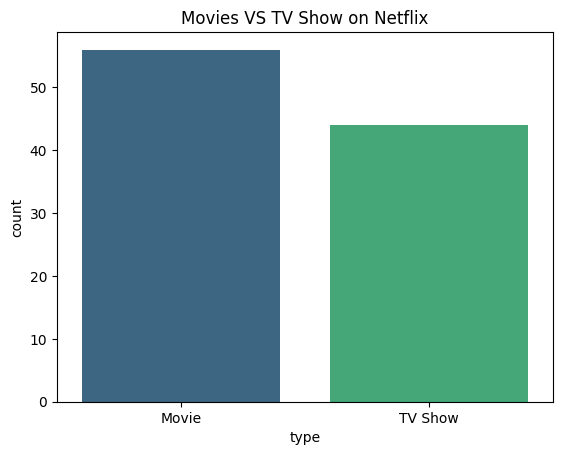

C:\Users\91935\AppData\Local\Temp\ipykernel_15676\1659946776.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.value_counts, y =top_countries.index, palette="magma")


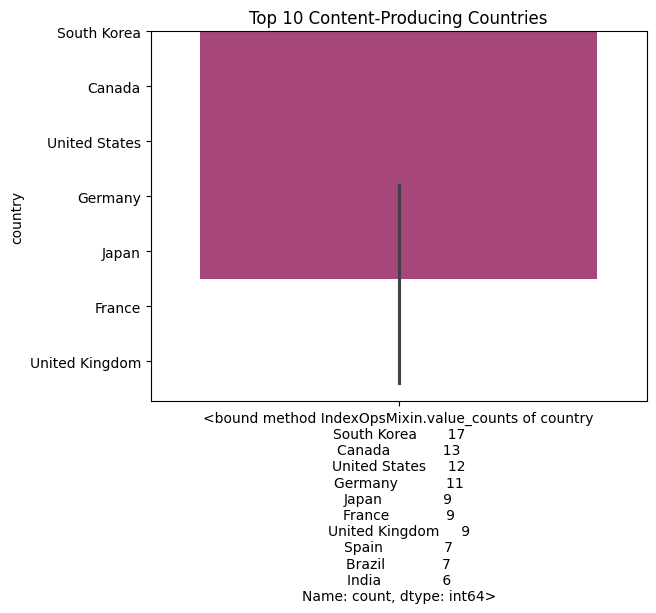

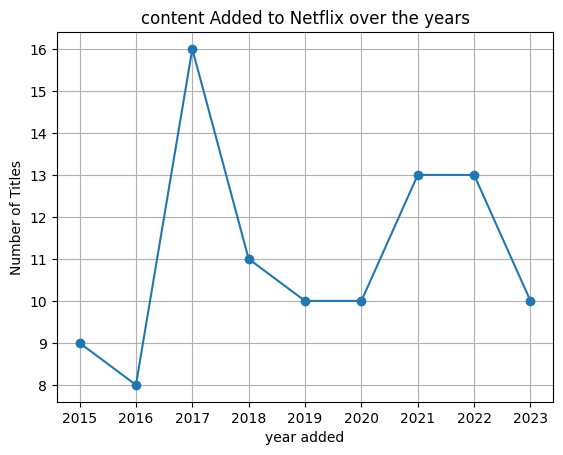

C:\Users\91935\AppData\Local\Temp\ipykernel_15676\1659946776.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_genres.value_counts, y = top_genres.index, palette="cool")


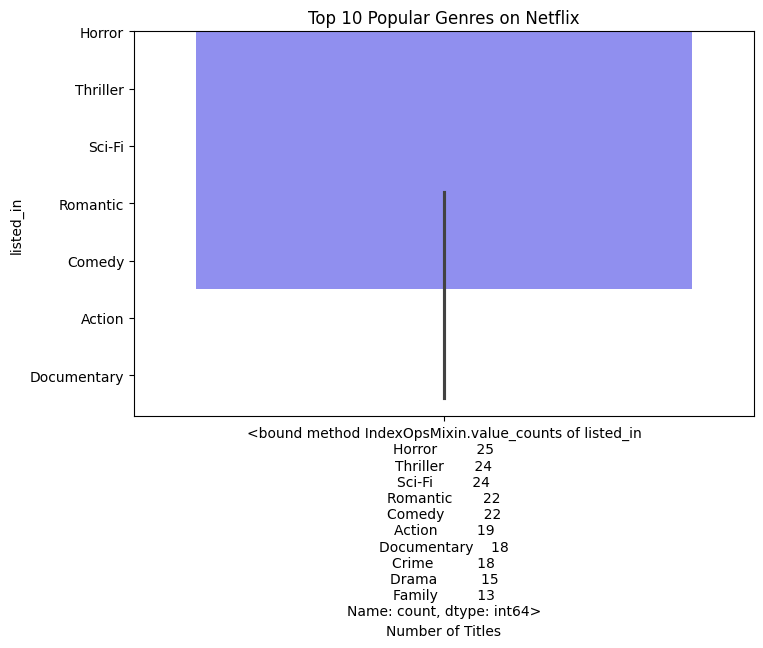

C:\Users\91935\AppData\Local\Temp\ipykernel_15676\1659946776.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_directors.values, y = top_directors.index,palette = "rocket")


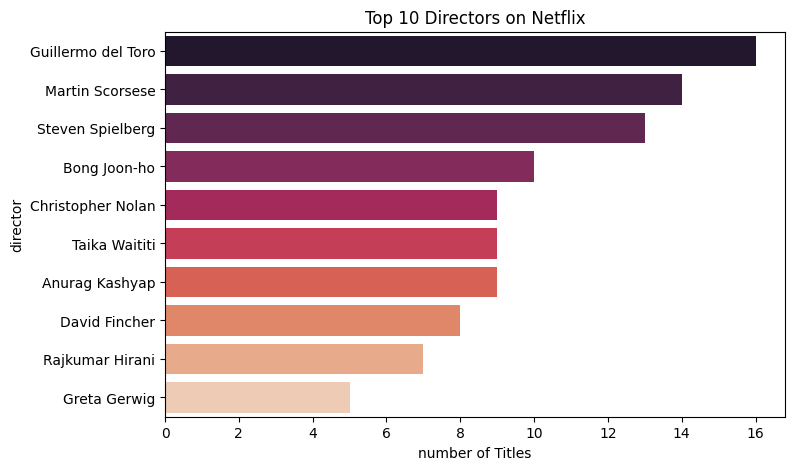

<function matplotlib.pyplot.show(close=None, block=None)>

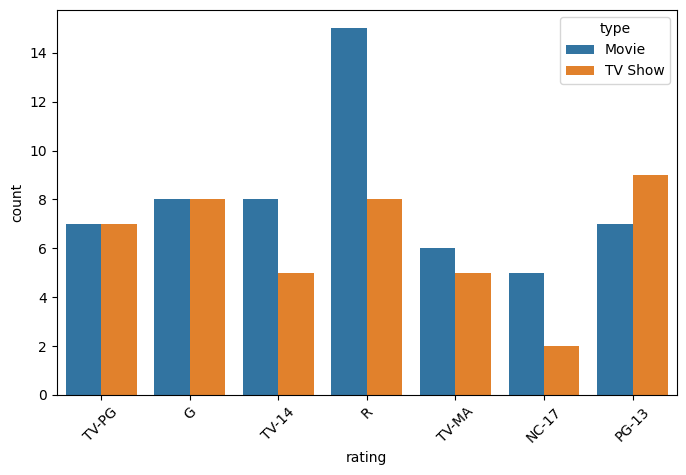

In [12]:
plt.Figure(figsize=(6,4))
sns.countplot(data = df , x= "type", palette="viridis")
plt.title("Movies VS TV Show on Netflix")
plt.show()

# top 10 country
top_countries = df["country"].value_counts().head(10)
plt.Figure(figsize=(8,5))
sns.barplot(x=top_countries.value_counts, y =top_countries.index, palette="magma")
plt.title('Top 10 Content-Producing Countries')
plt.show()

# Content added over time
df["year_added"] = df["date_added"].dt.year
yearly_trend = df["year_added"].value_counts().sort_index()
plt.Figure(figsize=(10,5))
plt.plot(yearly_trend.index, yearly_trend.values , marker = "o")
plt.title("content Added to Netflix over the years")
plt.xlabel("year added")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

# Top 10 Genres
df["listed_in"] =df["listed_in"].fillna("")
all_genres = df["listed_in"].str.split(',').explode().str.strip()
top_genres = all_genres.value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x = top_genres.value_counts, y = top_genres.index, palette="cool")
plt.title("Top 10 Popular Genres on Netflix")
plt.xlabel("Number of Titles")
plt.show()

# Top 10 Directors
top_directors = df["director"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x = top_directors.values, y = top_directors.index,palette = "rocket")
plt.title("Top 10 Directors on Netflix")
plt.xlabel("number of Titles")
plt.show()

# correlation between Realease year and Rating ( if numerical)
plt.figure(figsize=(8,5))
sns.countplot(data = df , x ="rating", hue="type")
plt.xticks(rotation=45)
plt.show
